In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [6]:
df = pd.read_csv('maternal_data.csv')
df.head()

,age,bmi,blood_pressure,gestational_age,previous_c_section,previous_miscarriages,previous_preterm_birth,chronic_hypertension,diabetes,gestational_diabetes,preeclampsia_history,multiple_pregnancy,smoking,alcohol_use,family_history,hb_level,urine_protein,blood_glucose,risk_level
0,43,25.8,121/93,22,0,0,0,1,0,0,0,0,0,1,0,10.0,5.8,74.0,high
1,29,19.6,136/80,24,1,2,0,0,0,0,0,0,0,0,0,12.7,42.2,96.1,moderate
2,22,19.8,139/82,30,0,0,0,1,0,1,0,1,0,0,0,12.2,17.9,77.6,high
3,35,27.7,90/63,8,0,0,0,0,1,0,0,0,1,0,0,11.2,15.7,65.1,high
4,33,22.5,128/75,19,0,2,0,0,0,0,0,0,0,0,0,12.4,11.3,60.0,moderate


In [7]:
df.shape

(76645, 19)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76645 entries, 0 to 76644
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     76645 non-null  int64  
 1   bmi                     76645 non-null  float64
 2   blood_pressure          76645 non-null  object 
 3   gestational_age         76645 non-null  int64  
 4   previous_c_section      76645 non-null  int64  
 5   previous_miscarriages   76645 non-null  int64  
 6   previous_preterm_birth  76645 non-null  int64  
 7   chronic_hypertension    76645 non-null  int64  
 8   diabetes                76645 non-null  int64  
 9   gestational_diabetes    76645 non-null  int64  
 10  preeclampsia_history    76645 non-null  int64  
 11  multiple_pregnancy      76645 non-null  int64  
 12  smoking                 76645 non-null  int64  
 13  alcohol_use             76645 non-null  int64  
 14  family_history          76645 non-null

In [9]:
df.isnull().sum()

age                       0
bmi                       0
blood_pressure            0
gestational_age           0
previous_c_section        0
previous_miscarriages     0
previous_preterm_birth    0
chronic_hypertension      0
diabetes                  0
gestational_diabetes      0
preeclampsia_history      0
multiple_pregnancy        0
smoking                   0
alcohol_use               0
family_history            0
hb_level                  0
urine_protein             0
blood_glucose             0
risk_level                0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

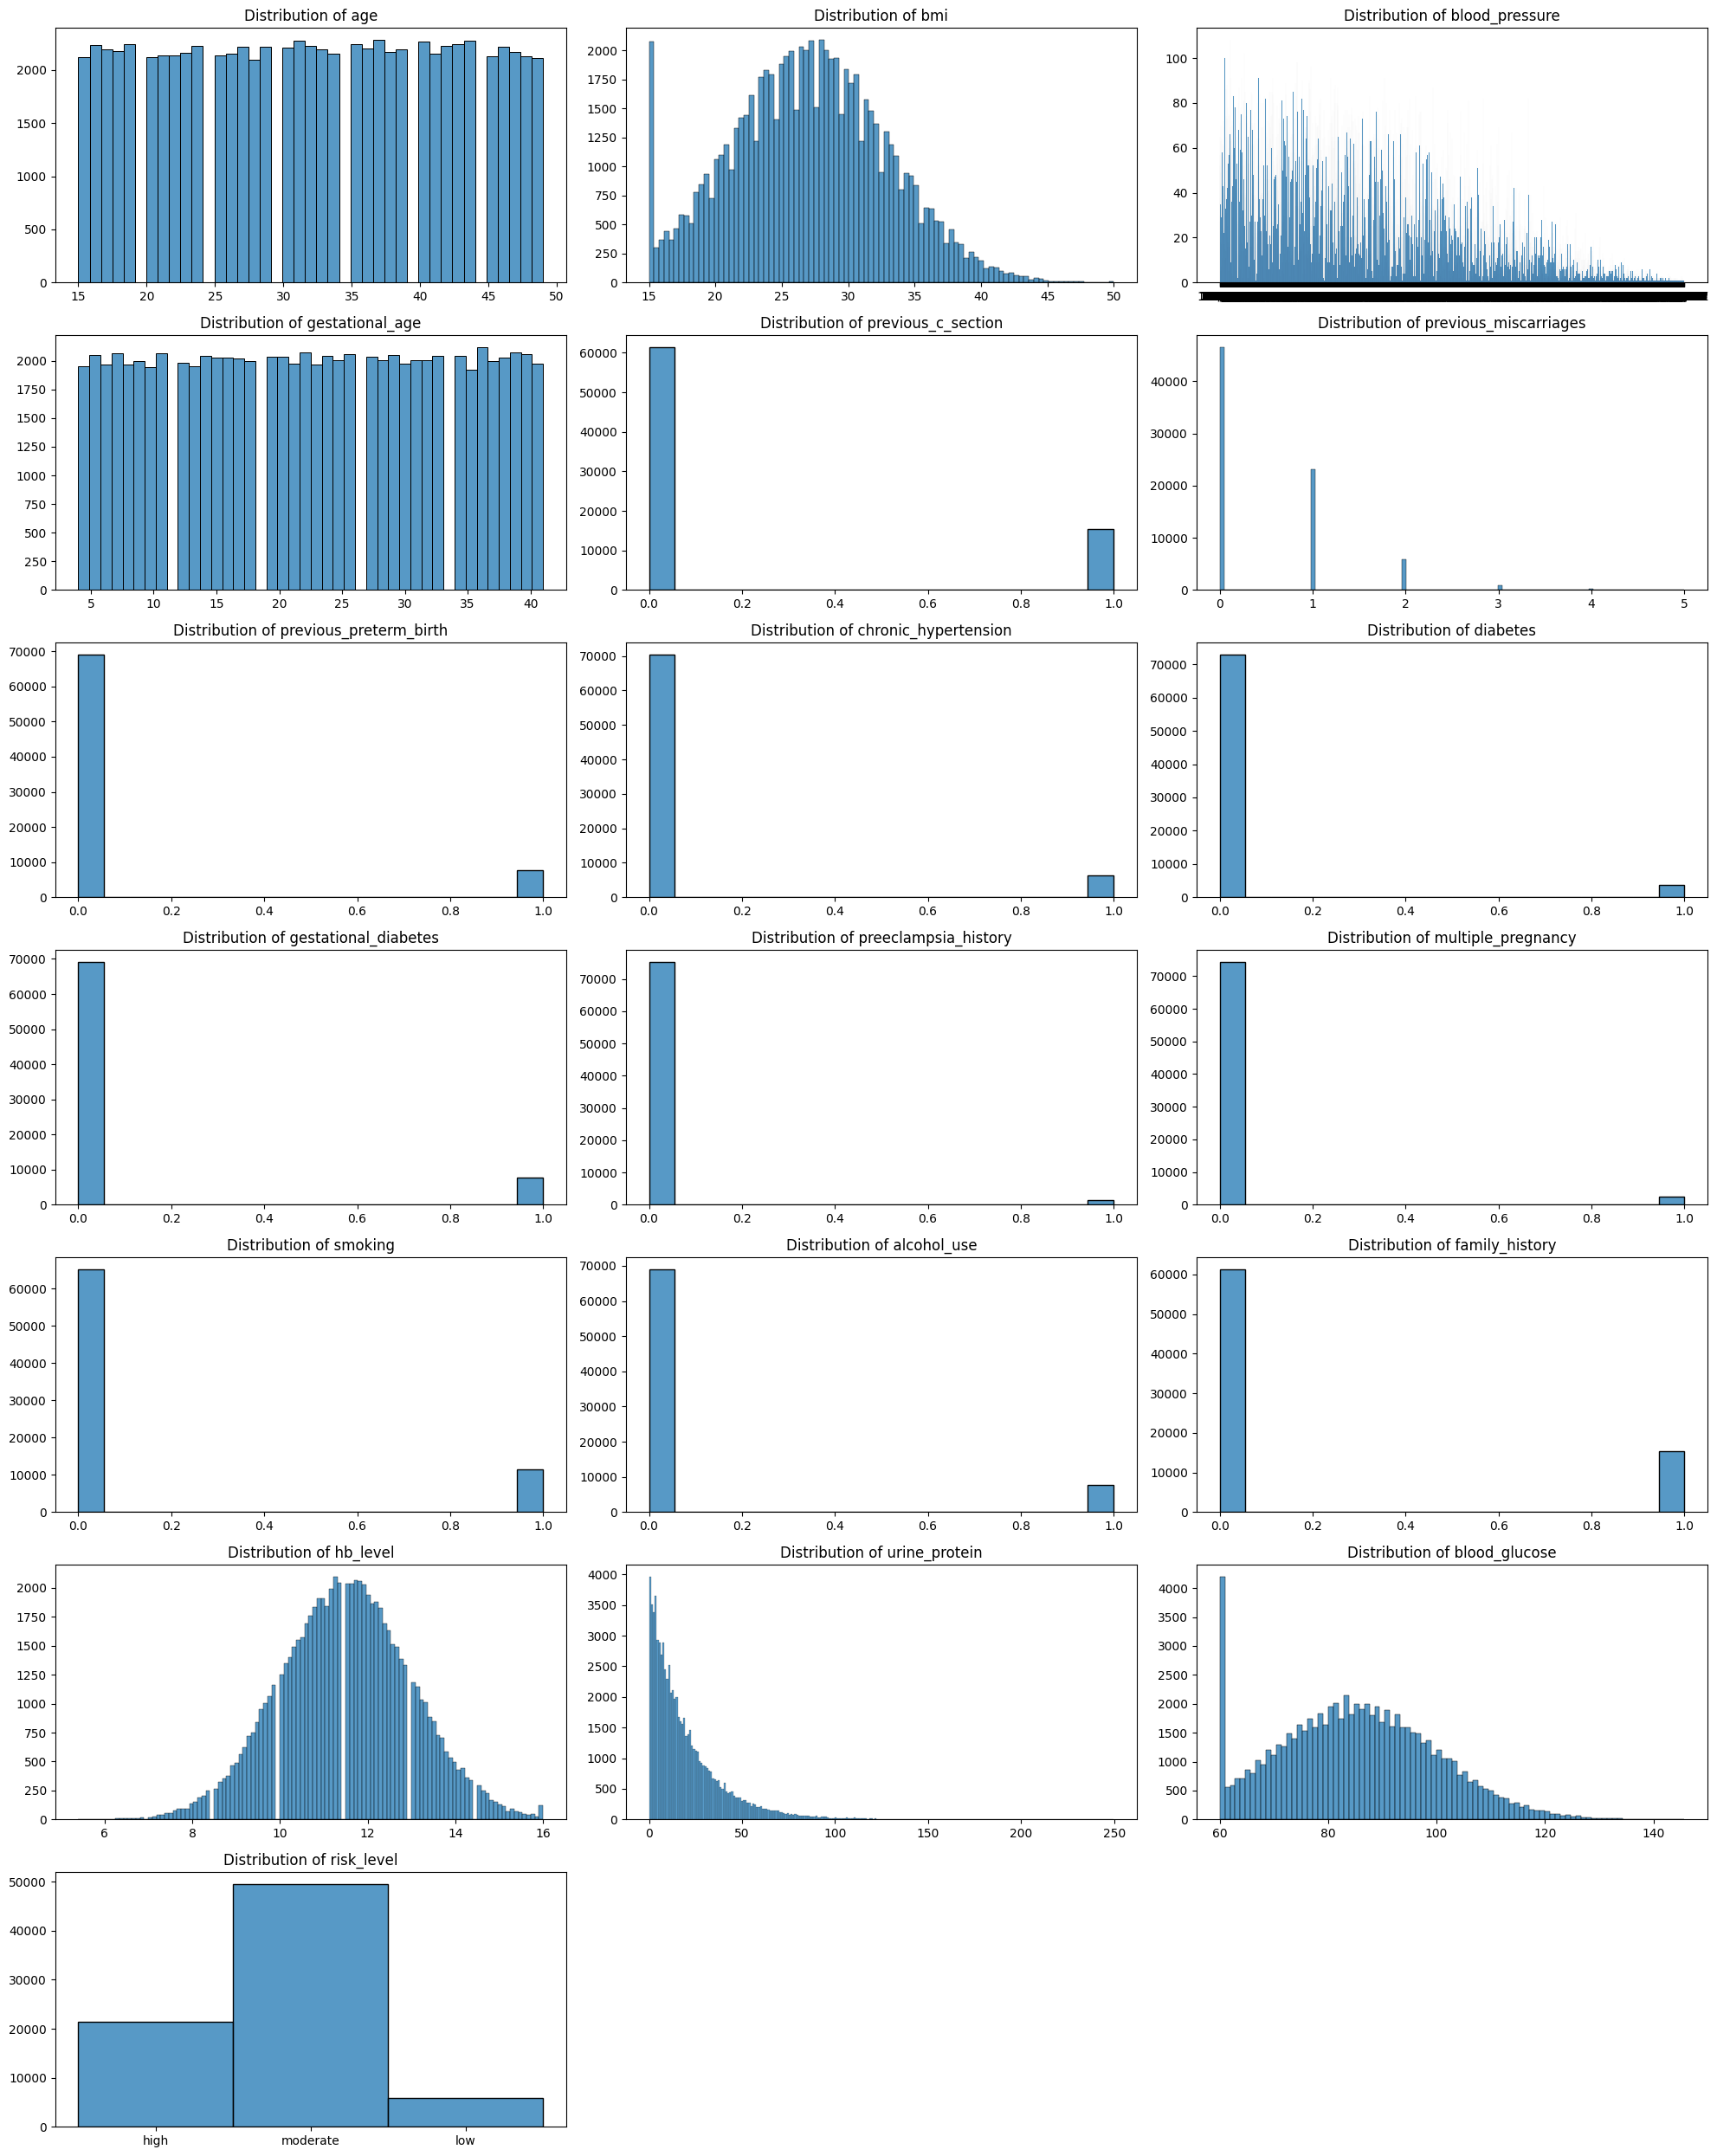

In [11]:
plt.figure(figsize=(20, 25))
feature_columns = df.columns

for i, column in enumerate(feature_columns, 1):
    plt.subplot(7, 3, i)
    sns.histplot(df[column])
    plt.title(f'Distribution of {column}')
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [12]:
label_encoder = LabelEncoder()
df['risk_level'] = label_encoder.fit_transform(df['risk_level'])
df.head()

,age,bmi,blood_pressure,gestational_age,previous_c_section,previous_miscarriages,previous_preterm_birth,chronic_hypertension,diabetes,gestational_diabetes,preeclampsia_history,multiple_pregnancy,smoking,alcohol_use,family_history,hb_level,urine_protein,blood_glucose,risk_level
0,43,25.8,121/93,22,0,0,0,1,0,0,0,0,0,1,0,10.0,5.8,74.0,0
1,29,19.6,136/80,24,1,2,0,0,0,0,0,0,0,0,0,12.7,42.2,96.1,2
2,22,19.8,139/82,30,0,0,0,1,0,1,0,1,0,0,0,12.2,17.9,77.6,0
3,35,27.7,90/63,8,0,0,0,0,1,0,0,0,1,0,0,11.2,15.7,65.1,0
4,33,22.5,128/75,19,0,2,0,0,0,0,0,0,0,0,0,12.4,11.3,60.0,2


In [13]:
df[['systolic', 'diastolic']] = df['blood_pressure'].str.split('/', expand=True)
df['systolic'] = pd.to_numeric(df['systolic'], errors='coerce')
df['diastolic'] = pd.to_numeric(df['diastolic'], errors='coerce')
df = df.drop('blood_pressure', axis=1)

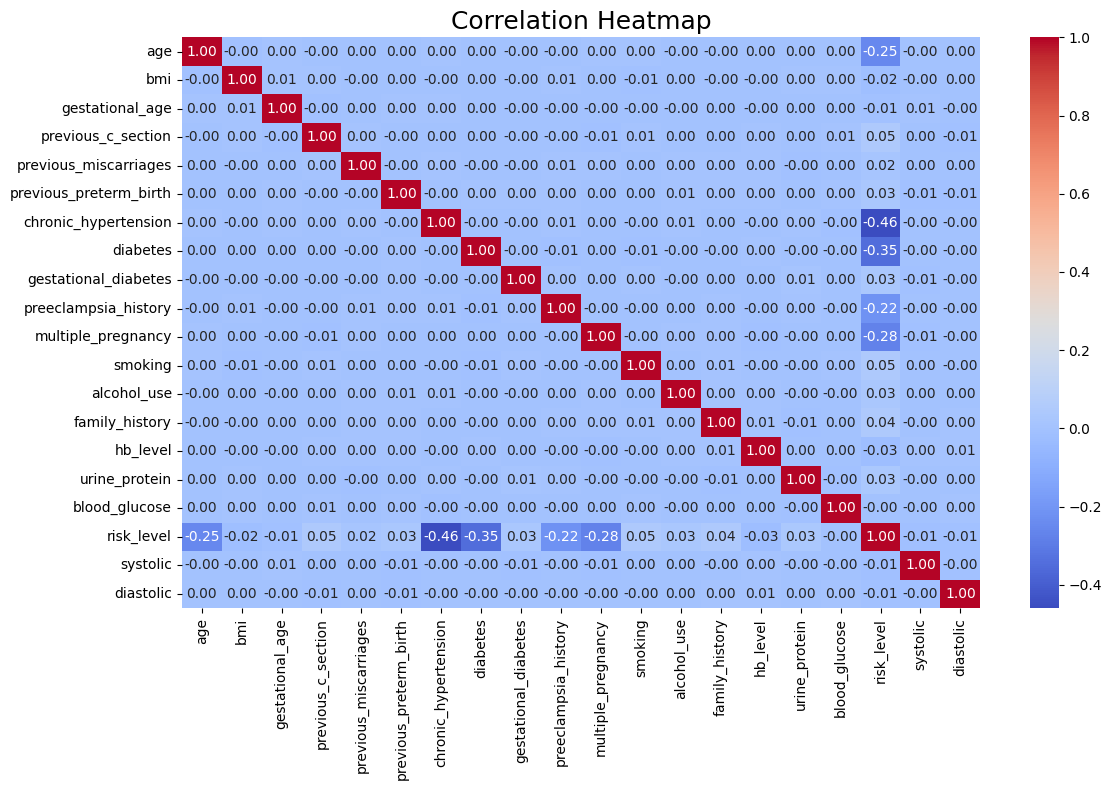

In [14]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt = '.2f')
plt.title("Correlation Heatmap", fontsize=18)
plt.tight_layout()
plt.show()

In [15]:
df.drop(['multiple_pregnancy', 'smoking', 'alcohol_use', 'family_history'], axis=1, inplace=True)
df.head()

,age,bmi,gestational_age,previous_c_section,previous_miscarriages,previous_preterm_birth,chronic_hypertension,diabetes,gestational_diabetes,preeclampsia_history,hb_level,urine_protein,blood_glucose,risk_level,systolic,diastolic
0,43,25.8,22,0,0,0,1,0,0,0,10.0,5.8,74.0,0,121,93
1,29,19.6,24,1,2,0,0,0,0,0,12.7,42.2,96.1,2,136,80
2,22,19.8,30,0,0,0,1,0,1,0,12.2,17.9,77.6,0,139,82
3,35,27.7,8,0,0,0,0,1,0,0,11.2,15.7,65.1,0,90,63
4,33,22.5,19,0,2,0,0,0,0,0,12.4,11.3,60.0,2,128,75


In [16]:
X = df.drop('risk_level', axis=1)
y = df['risk_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

LR_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {LR_accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.86

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.78      0.86      4246
           1       0.55      0.25      0.34      1170
           2       0.84      0.97      0.90      9913

    accuracy                           0.86     15329
   macro avg       0.78      0.66      0.70     15329
weighted avg       0.85      0.86      0.85     15329



In [19]:
model = DecisionTreeClassifier()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

DT_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {DT_accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.89

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      4246
           1       0.59      0.56      0.58      1170
           2       0.92      0.91      0.92      9913

    accuracy                           0.89     15329
   macro avg       0.80      0.80      0.80     15329
weighted avg       0.89      0.89      0.89     15329



In [28]:
model = XGBClassifier()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

XG_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {XG_accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
scaler = joblib.load('scaler.pkl')
model.load_model('xgboost_model.json')

Accuracy: 0.92

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      4246
           1       0.60      0.87      0.71      1170
           2       0.95      0.93      0.94      9913

    accuracy                           0.92     15329
   macro avg       0.85      0.90      0.87     15329
weighted avg       0.94      0.92      0.93     15329



XGBoostError: [18:54:16] C:\actions-runner\_work\xgboost\xgboost\src\common\io.cc:146: Opening xgboost_model.json failed: The system cannot find the file specified.

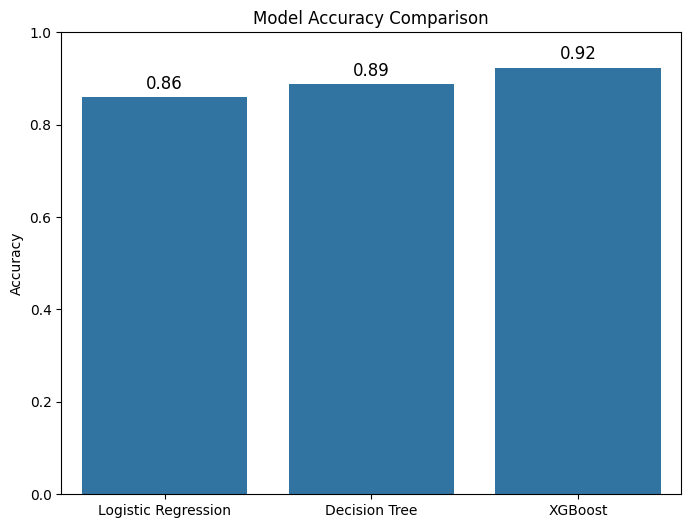

In [21]:
model_accuracies = {'Logistic Regression': LR_accuracy, 'Decision Tree': DT_accuracy, 'XGBoost': XG_accuracy}
plt.figure(figsize=(8, 6))
sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()))
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, (model, accuracy) in enumerate(model_accuracies.items()):
    plt.text(i, accuracy + 0.01, f"{accuracy:.2f}", ha='center', va='bottom', fontsize=12)
plt.show()

In [23]:
! pip install tensorflow


[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: C:\Users\Meherab\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
scaler = joblib.load('scaler.pkl')
model = xgb.XGBClassifier()
model.load_model('xgboost_model.json')

NameError: name 'encoder' is not defined